# AAindex の物理化学的指標の相関を調べる

## 1. 必要なライブラリのインポート

In [51]:
from aaindex import AAIndex1
import numpy as np
import math
import matplotlib.pyplot as plt

# 日本語文字化け対策
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    plt.rcParams['font.family'] = ['IPAexGothic', 'Noto Sans CJK JP', 'MS Gothic', 'Hiragino Sans', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False

In [6]:
def map_range(x, a, b, c, d):
    """
    変数 $x$ を 範囲 [$a$, $b$] から [$c$, $d$] にリマップします
    :param x: 変換する対象
    :param a: 変換前の下端
    :param b: 変換前の上端
    :param c: 変換後の下端
    :param d: 変換後の上端
    :return: リマップした値
    """
    return (x - a) / (b - a) * (d - c) + c

## 2. 偏りの大きい指標の除外
例えば指標 `VENT840101` は以下のようになっています。

```
VENT840101(2): {0.0, 1.0}
```

この場合、数値の種類が 2 種類しかなく、偏りが大きいので除外します。
今回は絞り込むために 20 種類のアミノ酸が全て異なるものを対象にしています。

In [22]:
aas = list("ACDEFGHIKLMNPQRSTVWY")
aaindex1 = AAIndex1()
filtered = {}  # 偏りの大きい指標は除外する


for i in aaindex1:
    only_aa = {k: v for k, v in aaindex1[i]["values"].items() if k in aas}
    nums = set(only_aa.values())
    print(f"{i}({len(nums)}): {nums}")

    if len(nums) == 20:
        filtered[i] = only_aa

ANDN920101(18): {3.97, 4.66, 4.35, 4.65, 4.76, 4.29, 4.63, 3.95, 4.36, 4.17, 4.52, 4.75, 4.44, 4.37, 4.38, 4.5, 4.7, 4.6}
ARGP820101(18): {0.61, 1.07, 2.02, 0.46, 0.47, 0.07, 2.22, 1.15, 1.53, 1.18, 1.95, 0.0, 2.65, 1.88, 0.05, 1.32, 0.6, 0.06}
ARGP820102(20): {0.49, 1.18, 1.96, 1.89, 0.31, 1.45, 0.06, 3.23, 2.67, 0.84, 1.08, 0.76, 0.05, 0.11, 0.77, 0.2, 0.23, 0.72, 0.97, 0.39}
ARGP820103(20): {0.14, 1.56, 2.03, 1.23, 0.62, 0.29, 1.67, 2.93, 2.96, 0.81, 1.08, 0.76, 0.51, 0.68, 0.27, 0.45, 0.23, 0.15, 1.14, 0.91}
AURR980101(17): {0.94, 0.6, 1.06, 1.41, 1.19, 1.18, 1.15, 1.07, 1.03, 0.95, 0.88, 0.69, 0.9, 0.91, 1.04, 0.79, 0.87}
AURR980102(15): {0.98, 1.05, 1.12, 0.41, 1.04, 1.25, 1.01, 0.88, 1.06, 0.8, 1.31, 0.9, 1.02, 1.14, 0.87}
AURR980103(17): {0.6, 1.05, 0.95, 1.39, 1.11, 1.26, 1.43, 0.97, 0.96, 0.99, 0.81, 1.06, 0.94, 0.87, 0.62, 1.03, 0.91}
AURR980104(18): {0.75, 0.66, 0.88, 1.1, 1.72, 1.14, 0.96, 0.8, 1.01, 1.02, 1.24, 1.33, 1.08, 0.9, 1.13, 0.68, 1.2, 0.58}
AURR980105(17): {0.67

In [39]:
correlates = {}

for i in filtered:
    values_r = filtered[i]
    vec_r = [values_r[aa] for aa in values_r if aa in aas]

    for j in filtered:
        if (j, i) in correlates:  # 対称性より (j, i) はスキップ
            continue

        if i != j:  # (i, i) もスキップする
            values_theta = filtered[j]
            vec_theta = [values_theta[aa] for aa in values_theta if aa in aas]
            # theta_base = [aa for aa in aaindex1[j]["values"] if aa in aas]
            # theta_min = np.min(theta_base)
            # theta_max = np.max(theta_base)
            # vec_theta = [map_range(aa, theta_min, theta_max, 10.0, 170.0) for aa in theta_base]

            correlates[(i, j)] = np.corrcoef(vec_r, vec_theta)[0, 1]

In [40]:
 # 1 に近いものを表示
tmp = sorted(correlates.items(), key=lambda x: x[1], reverse=True)
print("\033[31m[TOP 10 / 1]\033[0m")
for i in range(100):
    a, b = tmp[i]
    print(f"{a}: {float(b)}")

# 0 に近いものを表示
tmp = sorted(correlates.items(), key=lambda x: abs(x[1]))
print("\033[32m[TOP 10 / 0]\033[0m")
for i in range(100):
    a, b = tmp[i]
    print(f"{a}: {float(b)}")

# -1 に近いものを表示
tmp = sorted(correlates.items(), key=lambda x: x[1])
print("\033[34m[TOP 10 / -1]\033[0m")
for i in range(100):
    a, b = tmp[i]
    print(f"{a}: {float(b)}")

[TOP 10 / 1]
('LEVM780102', 'PRAM900103'): 1.0
('ENGD860101', 'PRAM900101'): 0.9999990866850761
('LEVM780103', 'PRAM900104'): 0.999782135473675
('TSAJ990101', 'TSAJ990102'): 0.9997733310597356
('CHOC750101', 'TSAJ990102'): 0.9958108983869267
('CHOC750101', 'TSAJ990101'): 0.9949579098331426
('CORJ870105', 'CORJ870106'): 0.9910562847899074
('GUYH850104', 'JANJ780101'): 0.9887597671730295
('HARY940101', 'PONJ960101'): 0.9887314016227298
('LEVM760102', 'LEVM760105'): 0.9869692239688369
('FUKS010105', 'FUKS010106'): 0.9820484105665297
('NISK800101', 'PONP800108'): 0.9763560882569243
('CORJ870101', 'NISK800101'): 0.9757040824985788
('CORJ870103', 'CORJ870107'): 0.9693698720222856
('CORJ870101', 'PONP800108'): 0.969362690491263
('CORJ870105', 'CORJ870107'): 0.9675040148412996
('MANP780101', 'PONP930101'): 0.9674695255050332
('GEIM800108', 'GEIM800111'): 0.9670505635895413
('GUYH850104', 'OOBM770101'): 0.9659533286164018
('CHOC750101', 'PONJ960101'): 0.9655355864253824
('NISK800101', 'PONP8001

## 3. 指標IDから直交座標ベクトルの作成

In [60]:
id_r = "NAKH900107"
id_theta = "PALJ810108"

vec_r = filtered[id_r]

vec_theta_tmp = filtered[id_theta]
thetas = [float(v) for k, v in vec_theta_tmp.items()]
theta_min = float(np.min(thetas))
theta_max = float(np.max(thetas))
vec_theta = {k: map_range(v, theta_min, theta_max, 10.0, 170.0) for k, v in vec_theta_tmp.items()}

VECTOR = {aa: {"x": vec_r[aa] * math.cos(math.radians(vec_theta[aa])), "y": vec_r[aa] * math.sin(math.radians(vec_theta[aa]))} for aa in aas}

for aa in aas:
    print(f"\"{aa}\": {VECTOR[aa]},")



"A": {'x': -3.021716477288284, 'y': 4.463331662657894},
"C": {'x': -0.36233629033978615, 'y': 0.7799438522757918},
"D": {'x': 0.14049283824157704, 'y': 3.066783618451557},
"E": {'x': -2.6589809331329617, 'y': 0.4688500797007118},
"F": {'x': 0.8679844072348316, 'y': 6.2803027848024335},
"G": {'x': 6.420946549639596, 'y': 1.1321861183883857},
"H": {'x': -0.15301086574475964, 'y': 2.224744406659794},
"I": {'x': 5.189997855903639, 'y': 8.477471454137468},
"K": {'x': -7.509932773989893e-16, 'y': 4.67},
"L": {'x': -8.235118420374606, 'y': 9.589182686882488},
"M": {'x': 1.47367037279666, 'y': 3.372046208512178},
"N": {'x': 3.9584804546017334, 'y': 6.14544811145095},
"P": {'x': 3.549682926508577, 'y': 0.7100359999700732},
"Q": {'x': -0.2637976987810208, 'y': 2.2948879654828116},
"R": {'x': 1.0660486448932056, 'y': 2.599930823449224},
"S": {'x': 0.49677070313544736, 'y': 7.222936997406686},
"T": {'x': 3.8190475950097964, 'y': 3.8740773697810806},
"V": {'x': -1.402255015870612, 'y': 6.0188105860

## 4. プロットして確認

In [55]:
def plot_amino_vectors(VECTOR, vec_r, vec_theta, id_r, id_theta, aas):
    """
    20種類のアミノ酸ベクトルを 3 つのサブプロットで可視化する。

    :param VECTOR: {aa: {"x": ..., "y": ...}} の辞書
    :param vec_r: {aa: r値} の辞書（動径用の元データ）
    :param vec_theta: {aa: θ値[degree]} の辞書（スケーリング後）
    :param id_r: 動径に使った AAindex ID
    :param id_theta: 偏角に使った AAindex ID
    :param aas: アミノ酸 1 文字記号のリスト
    """
    # アミノ酸ごとに色を割り当てる（カラーマップ）
    cmap = plt.get_cmap("tab20")
    colors = {aa: cmap(i / len(aas)) for i, aa in enumerate(aas)}

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))

    # =========================================================
    # (1) 直交座標 (x, y) でのベクトル表示
    # =========================================================
    ax = axes[0]
    xs = [VECTOR[aa]["x"] for aa in aas]
    ys = [VECTOR[aa]["y"] for aa in aas]

    # 原点からの矢印
    for aa in aas:
        ax.annotate(
            "",
            xy=(VECTOR[aa]["x"], VECTOR[aa]["y"]),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color=colors[aa], lw=1.5, alpha=0.7),
        )

    # 点と文字ラベル
    for aa in aas:
        ax.scatter(VECTOR[aa]["x"], VECTOR[aa]["y"],
                   color=colors[aa], s=80, zorder=3, edgecolors="black", linewidths=0.5)
        ax.annotate(aa, (VECTOR[aa]["x"], VECTOR[aa]["y"]),
                    fontsize=11, fontweight="bold",
                    xytext=(5, 5), textcoords="offset points")

    # 原点
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.scatter([0], [0], color="black", s=30, zorder=4)

    # アスペクト比を 1:1 に固定
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(f"直交座標表示 (x, y)\nr: {id_r} / θ: {id_theta}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)

    # =========================================================
    # (2) 極座標表示
    # =========================================================
    ax = plt.subplot(1, 3, 2, projection="polar")
    for aa in aas:
        theta_rad = math.radians(vec_theta[aa])
        r = vec_r[aa]
        ax.plot([0, theta_rad], [0, r], color=colors[aa], lw=1.5, alpha=0.7)
        ax.scatter(theta_rad, r, color=colors[aa], s=80,
                   edgecolors="black", linewidths=0.5, zorder=3)
        ax.annotate(aa, xy=(theta_rad, r),
                    fontsize=11, fontweight="bold",
                    xytext=(5, 5), textcoords="offset points")

    ax.set_title(f"極座標表示 (r, θ)\nr: {id_r} / θ: {id_theta}\n"
                 f"θ ∈ [10°, 170°]", pad=20)
    ax.set_thetamin(0)
    ax.set_thetamax(180)  # θ ∈ [10°, 170°] が見える範囲
    ax.grid(alpha=0.3)

    # =========================================================
    # (3) 散布図のみ（重なり確認用）
    # =========================================================
    ax = axes[2]
    for aa in aas:
        ax.scatter(VECTOR[aa]["x"], VECTOR[aa]["y"],
                   color=colors[aa], s=150, zorder=3,
                   edgecolors="black", linewidths=0.8)
        ax.annotate(aa, (VECTOR[aa]["x"], VECTOR[aa]["y"]),
                    fontsize=12, fontweight="bold",
                    ha="center", va="center", color="white")

    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title("散布図（ラベル付き）\nアミノ酸の分布確認")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_sample_walk(VECTOR, sequence, aas, title=""):
    """
    サンプルアミノ酸配列を入力として、グラフ表示画像と同等の累積パスを描画。
    実際にグラフ画像化したときにどのような形になるかを事前確認できる。

    :param VECTOR: {aa: {"x": ..., "y": ...}} の辞書
    :param sequence: アミノ酸配列文字列 (例: "MKLVT...")
    :param aas: アミノ酸 1 文字記号のリスト
    :param title: グラフタイトル
    """
    x, y = 0.0, 0.0
    xs, ys = [x], [y]

    for c in sequence:
        if c not in VECTOR:
            continue
        x += VECTOR[c]["x"]
        y += VECTOR[c]["y"]
        xs.append(x)
        ys.append(y)

    fig, ax = plt.subplots(figsize=(8, 8))

    # 線をグラデーションで描く（開始 → 終了が分かるように）
    n = len(xs) - 1
    cmap = plt.get_cmap("viridis")
    for i in range(n):
        ax.plot(xs[i:i+2], ys[i:i+2],
                color=cmap(i / max(n - 1, 1)), lw=1.5, alpha=0.8)

    # 始点と終点
    ax.scatter(xs[0], ys[0], color="green", s=120, zorder=5,
               edgecolors="black", label="Start")
    ax.scatter(xs[-1], ys[-1], color="red", s=120, zorder=5,
               edgecolors="black", label="End")

    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(f"サンプル配列のパス描画\n{title}\n配列長: {len(sequence)}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

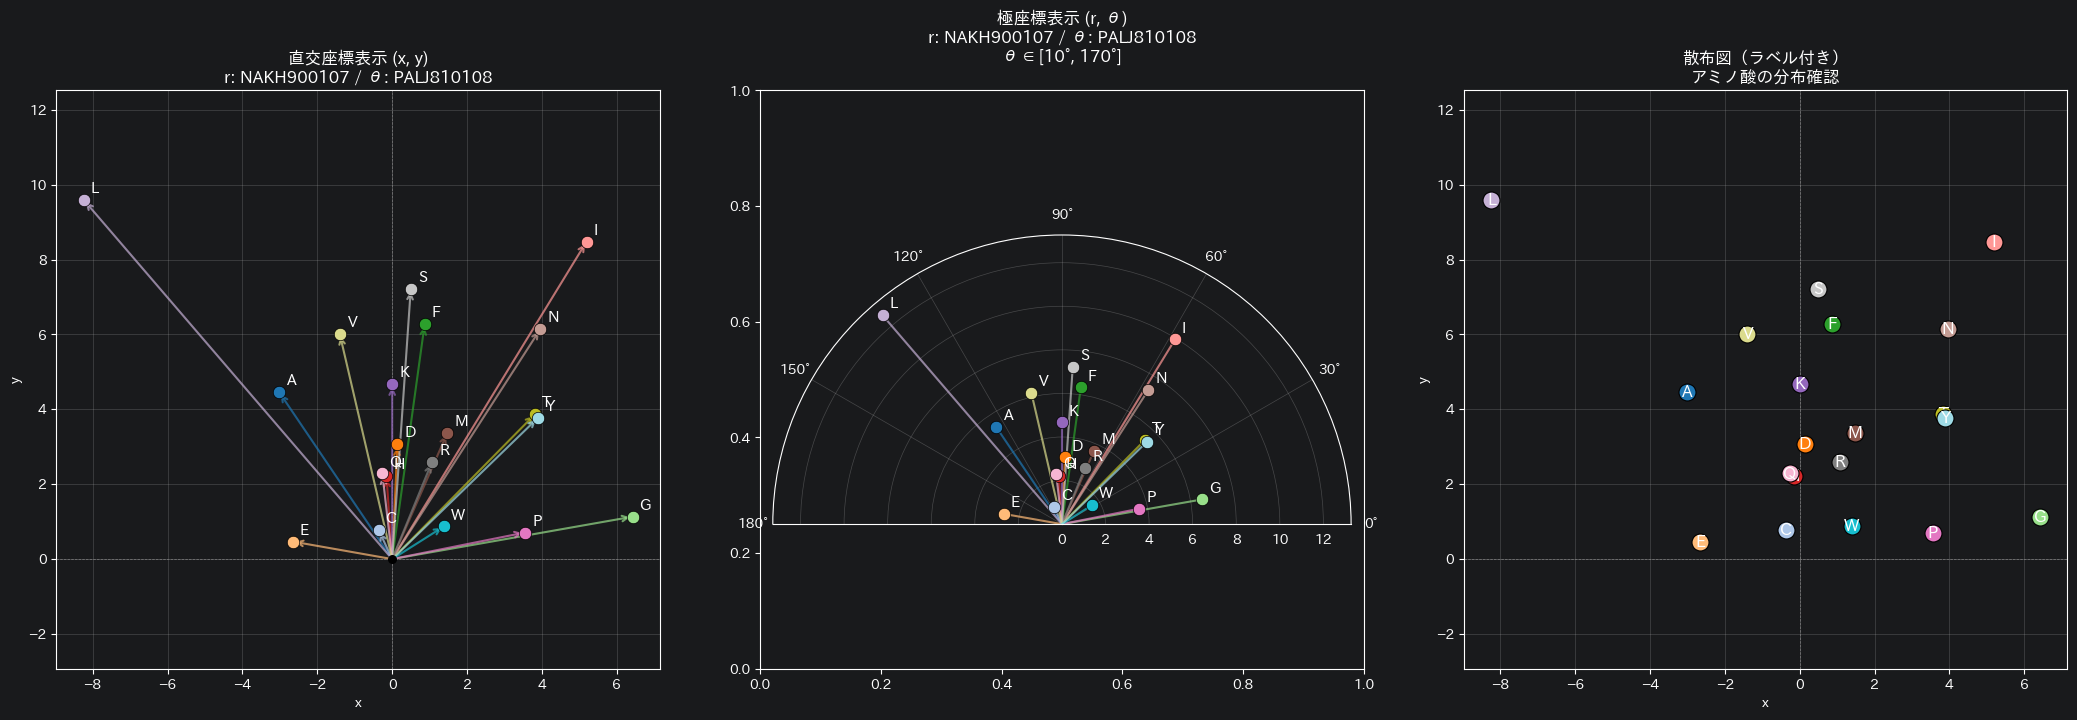

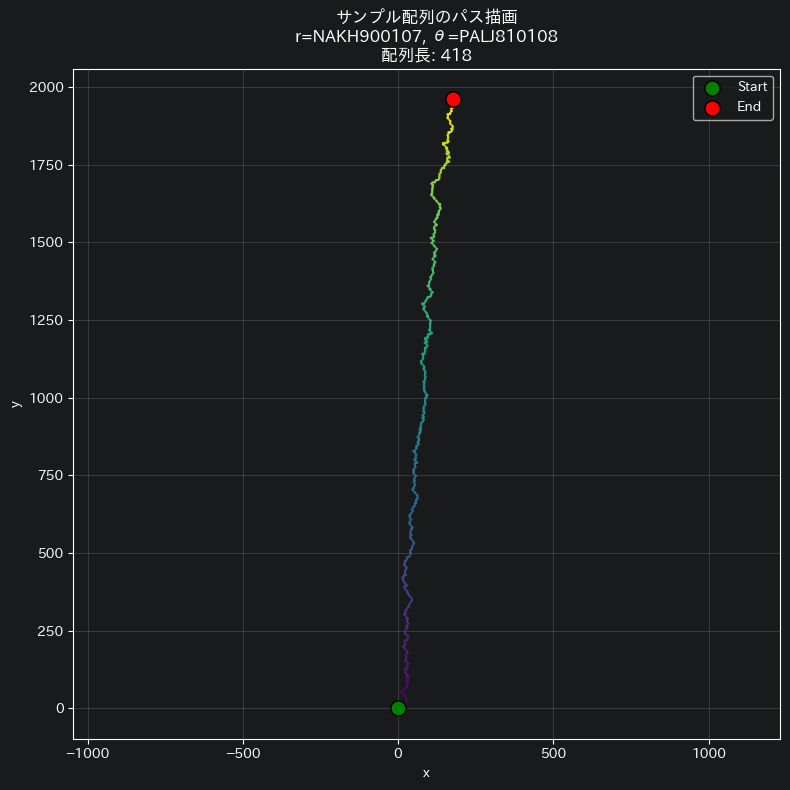

In [57]:
plot_amino_vectors(VECTOR, vec_r, vec_theta, id_r, id_theta, aas)

# --- サンプル配列でパス描画（任意）---
sample_seq = "MGPPGNDSDFLLTTNGSHVPDHDVTEERDEAWVVGMAILMSVIVLAIVFGNVLVITAIAKFERLQTVTNYFITSLACADLVMGLAVVPFGASHILMKMWNFGNFWCEFWTSIDVLCVTASIETLCVIAVDRYIAITSPFKYQSLLTKNKARMVILMVWIVSGLTSFLPIQMHWYRATHQKAIDCYHKETCCDFFTNQAYAIASSIVSFYVPLVVMVFVYSRVFQVAKRQLQKIDKSEGRFHSPNLGQVEQDGRSGHGLRRSSKFCLKEHKALKTLGIIMGTFTLCWLPFFIVNIVHVIQDNLIPKEVYILLNWLGYVNSAFNPLIYCRSPDFRIAFQELLCLRRSSSKAYGNGYSSNSNGKTDYMGEASGCQLGQEKESERLCEDPPGTESFVNCQGTVPSLSLDSQGRNCSTNDSPL"
plot_sample_walk(VECTOR, sample_seq, aas, title=f"r={id_r}, θ={id_theta}")